# Modèle Statistique - Facteurs influençant le Mariage Précoce

Ce notebook présente l'analyse exploratoire et le modèle de régression logistique binaire basé sur les données EDS Cameroun 2018.

## Pourquoi un Modèle Statistique ?
L'objectif d'un modèle statistique classique (comme la Régression Logistique) par rapport au Machine Learning pur, est l'**explicabilité**. Nous cherchons ici à quantifier exactement *l'impact* de chaque facteur (ex: vivre en zone rurale augmente le risque de X fois) grâce aux **Odds Ratios** (Rapports de Cotes).

## 1. Importation des bibliothèques, Architecture et Chargement

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import chi2_contingency
from pathlib import Path
import scipy.stats as ss

# Style graphique professionnel
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')

# Architecture de sortie
ROOT = Path.cwd()
PROJECT_ROOT = ROOT
OUTPUTS_DIR = PROJECT_ROOT / 'outputs'
TABLE_DIR = OUTPUTS_DIR / 'tables'
FIG_DIR = OUTPUTS_DIR / 'figures'

OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Chargement simple des données
try:
    df = pd.read_excel('Dataset_Mariage_Precoce_V2.xlsx', sheet_name='data')
    print("Données chargées avec succès. Dimensions :", df.shape)
except Exception as e:
    print("Erreur lors du chargement des données :", e)

Erreur lors du chargement des données : [Errno 2] No such file or directory: 'Dataset_Mariage_Precoce_V2.xlsx'


## 2. Preprocessing des données
Le nettoyage des données est une étape fondamentale. Les valeurs aberrantes ont été écartées lors de la génération du jeu de données.

In [11]:
# Typage des variables catégorielles
categorical_cols = ['Region', 'Type_Residence', 'Niveau_Education', 'Religion', 'Indice_Richesse', 'Statut_Emploi', 'Ecoute_Radio', 'Regarde_TV']
for col in categorical_cols:
    df[col] = df[col].astype('category')

# Définition de X et y
y_col = 'Mariage_Precoce'
y = df[y_col]
X = df.drop(columns=[y_col, 'Statut_Matrimonial', 'Age_Premier_Mariage']) 


## 3. Analyse Exploratoire

### 3.1. Analyse Univariée
L'analyse univariée permet de comprendre la distribution individuelle de chaque variable avant d'analyser leurs relations.

C:\Users\DELL\AppData\Local\Temp\ipykernel_4624\2955971721.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=y_col, data=df, palette='Set2')


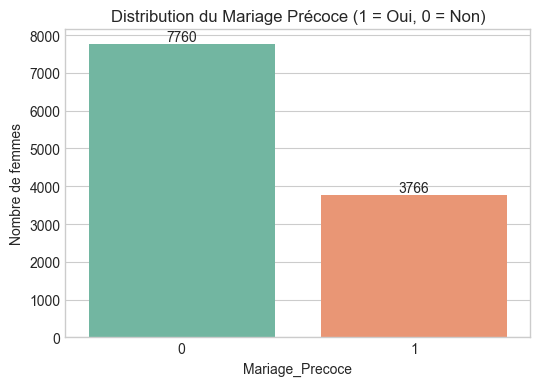

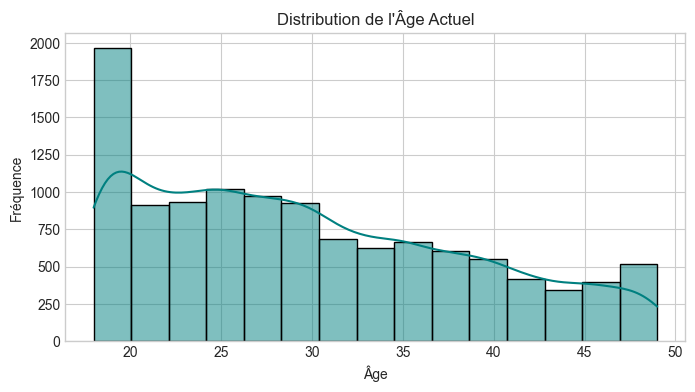

In [12]:
# Distribution de la variable cible
plt.figure(figsize=(6, 4))
ax = sns.countplot(x=y_col, data=df, palette='Set2')
plt.title('Distribution du Mariage Précoce (1 = Oui, 0 = Non)')
plt.ylabel('Nombre de femmes')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=10)
plt.savefig(FIG_DIR / 'dist_mariage_precoce.png', bbox_inches='tight')
plt.show()

# Distribution de l'âge actuel
plt.figure(figsize=(8, 4))
sns.histplot(df['Age_Actuel'], bins=15, kde=True, color='teal')
plt.title('Distribution de l\'Âge Actuel')
plt.xlabel('Âge')
plt.ylabel('Fréquence')
plt.savefig(FIG_DIR / 'dist_age.png', bbox_inches='tight')
plt.show()

### 3.2. Analyse Bivariée (X vs Y)
**Le Test du Chi-2 d'indépendance** permet de vérifier si deux variables catégorielles sont significativement liées. Une *p-value* < 0.05 indique que la relation observée n'est pas due au hasard.

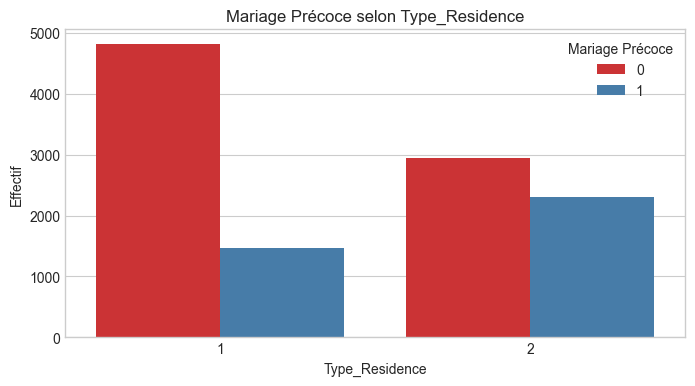

Test Chi-2 pour Type_Residence : p-value = 5.9088e-121


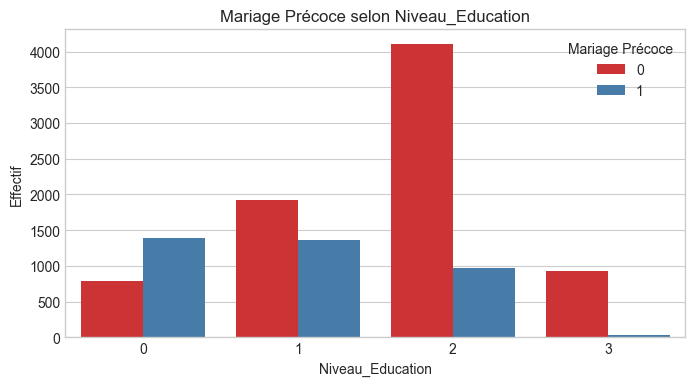

Test Chi-2 pour Niveau_Education : p-value = 0.0000e+00


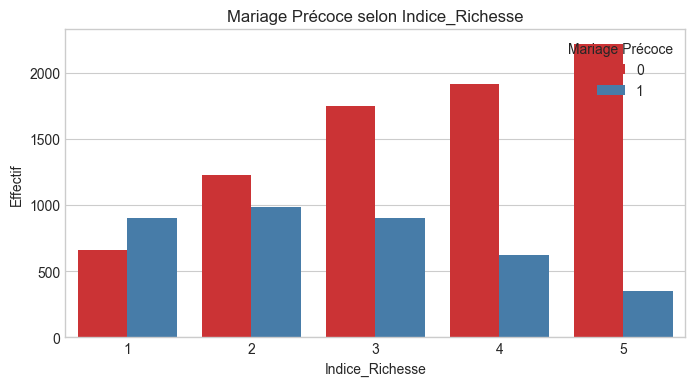

Test Chi-2 pour Indice_Richesse : p-value = 1.2039e-233


In [13]:
vars_to_plot = ['Type_Residence', 'Niveau_Education', 'Indice_Richesse']

biv_results = []
for var in vars_to_plot:
    plt.figure(figsize=(8, 4))
    sns.countplot(x=var, hue=y_col, data=df, palette='Set1')
    plt.title(f'Mariage Précoce selon {var}')
    plt.ylabel('Effectif')
    plt.legend(title='Mariage Précoce', loc='upper right')
    plt.savefig(FIG_DIR / f'biv_{var}.png', bbox_inches='tight')
    plt.show()
    
    contingency_table = pd.crosstab(df[var], df[y_col])
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    biv_results.append({'Variable': var, 'Chi-2': chi2, 'p-value': p})
    print(f"Test Chi-2 pour {var} : p-value = {p:.4e}")

pd.DataFrame(biv_results).to_csv(TABLE_DIR / 'chi2_results.csv', index=False)


### 3.3. Analyse Multivariée Strictement Conforme
**Bonnes Pratiques Statistiques :** La matrice de corrélation classique (Pearson) requiert des variables continues. Puisque la majorité de nos variables sont catégorielles, nous utilisons le **V de Cramér**, qui mesure l'intensité de l'association entre variables nominales (0 = aucune association, 1 = association parfaite). L'objectif est de vérifier l'absence de colinéarité excessive (variables qui disent exactement la même chose).

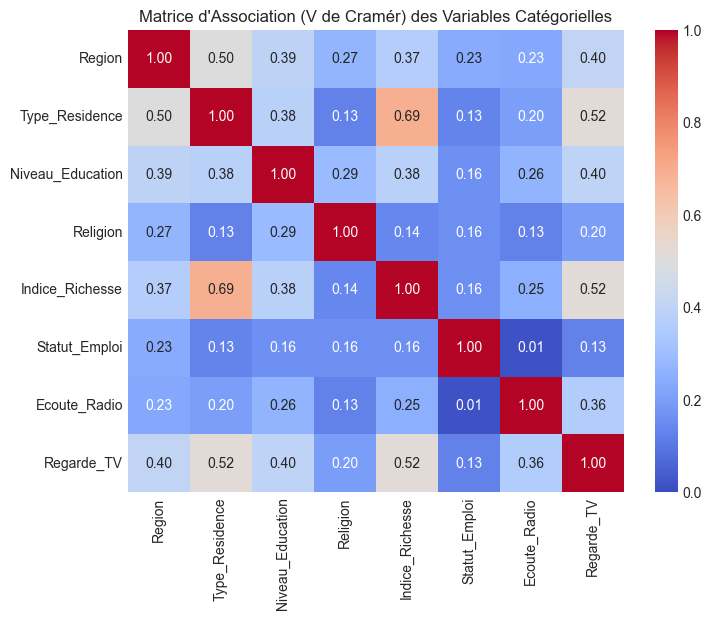

In [14]:
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = ss.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    return np.sqrt(phi2 / min(k-1, r-1))

corr_matrix = pd.DataFrame(index=categorical_cols, columns=categorical_cols)
for col1 in categorical_cols:
    for col2 in categorical_cols:
        corr_matrix.loc[col1, col2] = cramers_v(df[col1], df[col2])

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix.astype(float), annot=True, cmap='coolwarm', vmin=0, vmax=1, fmt=".2f")
plt.title("Matrice d'Association (V de Cramér) des Variables Catégorielles")
plt.savefig(FIG_DIR / 'cramer_v_matrix.png', bbox_inches='tight')
plt.show()

corr_matrix.to_csv(TABLE_DIR / 'cramer_v_matrix.csv')

## 4. Modèle Statistique (Régression Logistique Binaire)
Nous modélisons la probabilité qu'une femme se marie avant 18 ans. Le modèle GLM (Generalized Linear Model) de la famille Binomiale permet de prendre en compte les **Poids de sondage (V005)** de l'EDS, ce qui est crucial pour que notre échantillon reste représentatif de la population camerounaise totale.

In [15]:
# Encodage Dummy pour éviter le piège de la colinéarité (drop_first=True)
X_model = pd.get_dummies(df[categorical_cols], drop_first=True)
X_model['Age_Actuel'] = df['Age_Actuel']

X_model = sm.add_constant(X_model.astype(float))
y_model = y.astype(float)

weights = df['Poids_Sondage']
logit_model = sm.GLM(y_model, X_model, family=sm.families.Binomial(), freq_weights=weights)
result = logit_model.fit()

summary_html = result.summary().as_html()
with open(TABLE_DIR / 'regression_summary.html', 'w', encoding='utf-8') as f:
    f.write(summary_html)

print(result.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:        Mariage_Precoce   No. Observations:                11526
Model:                            GLM   Df Residuals:                 11587.03
Model Family:                Binomial   Df Model:                           31
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -6014.2
Date:                Wed, 20 May 2026   Deviance:                       12028.
Time:                        19:07:49   Pearson chi2:                 1.15e+04
No. Iterations:                     6   Pseudo R-squ. (CS):             0.2169
Covariance Type:            nonrobust                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -0.4277      0

## 5. Interprétation : Odds Ratios (Rapports de Cotes)
**Théorie :** Un coefficient logit brut est difficile à interpréter. En passant ce coefficient à l'exponentielle, on obtient l'**Odds Ratio**. 
- Si OR > 1 : Le facteur augmente le risque de mariage précoce.
- Si OR < 1 : Le facteur diminue ce risque.
- Si OR = 1 : Aucun effet.

In [16]:
coeffs = result.params
print("Équation de la régression logistique :")
print(f"Logit(P) = {coeffs['const']:.4f}", end=" ")
for var, coef in coeffs.items():
    if var != 'const':
        sign = "+" if coef >= 0 else "-"
        print(f"\n           {sign} {abs(coef):.4f} * {var}", end=" ")
print("\n")

odds_ratios = pd.DataFrame({'Odds Ratio': np.exp(coeffs), 'p-value': result.pvalues})
odds_ratios.to_csv(TABLE_DIR / 'odds_ratios.csv')
print("Odds Ratios sauvegardés dans outputs/tables/odds_ratios.csv")
print(odds_ratios)

Équation de la régression logistique :
Logit(P) = -0.4277 
           - 0.1882 * Region_2 
           - 0.4700 * Region_3 
           + 0.1174 * Region_4 
           + 0.1796 * Region_5 
           - 0.5963 * Region_6 
           + 0.1438 * Region_7 
           - 0.5719 * Region_8 
           - 0.3045 * Region_9 
           - 0.3375 * Region_10 
           - 0.6412 * Region_11 
           - 0.4164 * Region_12 
           + 0.2221 * Type_Residence_2 
           - 0.4411 * Niveau_Education_1 
           - 1.1763 * Niveau_Education_2 
           - 2.7456 * Niveau_Education_3 
           - 0.0028 * Religion_2 
           + 0.1140 * Religion_3 
           + 0.7433 * Religion_4 
           + 0.1403 * Religion_5 
           - 0.0370 * Religion_7 
           - 0.4205 * Religion_96 
           + 0.0385 * Indice_Richesse_2 
           - 0.0072 * Indice_Richesse_3 
           - 0.0691 * Indice_Richesse_4 
           - 0.2337 * Indice_Richesse_5 
           + 0.3206 * Statut_Emploi_1 
           -